# kAOV: Kernel Analysis Of Variance

In [24]:
import pandas as pd
from torch import concat
from kaov import AOV
import re

## Import data

Various functionalities of the library will be demonstrated on a single-cell RT-qPCR dataset (Zreika et al., 2022) with a 4-level experimental condition of interest (i.e. Medium), and an 8-level batch effect. In this tutorial we will focus on different ways to specify the model and tests.

The dataset contains the expression measurements of 83 genes on 685 cells. In this context single-cell transcriptomics has been performed to investigate the cell differentiation process of chicken primary erythroid progenitor cells. To investigate the impact of the medium on cell differentiation, undifferentiated cells were initially put in a self-renewal medium (`0H` level of the medium effect), then put in a differentiation-inducing medium for 24h (`24H`). The population was then split into a first population maintained in the same medium for an additional 24h to achieve differentiation (`48HDIFF`), the second population was put back in the self-renewal medium to investigate potential reversion (`48HREV`).

In [3]:
# Importing data:
url = "https://raw.githubusercontent.com/LMJL-Alea/kAOV/refs/heads/main/Data/reversion_kAOV.csv"
data = pd.read_csv(url, index_col=0)
# Specifying the formula for the dependent variables (genes):
form_exog = ' + '.join(data.columns[:-2])

In [4]:
data[['Batch', 'Medium']].value_counts(sort=False)

Batch  Medium 
REV1   0H         23
       24H        21
       48HDIFF    24
       48HREV     21
REV2   0H         23
       24H        24
       48HDIFF    22
       48HREV     21
REV3   0H         21
       24H        24
       48HDIFF    22
       48HREV     22
REV4   0H         18
       24H        21
       48HDIFF    19
       48HREV     19
REV5   0H         23
       24H        21
       48HDIFF    21
       48HREV     23
REV6   0H         20
       24H        22
       48HDIFF    22
       48HREV     22
REV7   0H         21
       24H        20
       48HDIFF    23
       48HREV     20
REV8   0H         24
       24H        20
       48HDIFF    15
       48HREV     23
Name: count, dtype: int64

## An additive model
Module `AOV` infers a linear model in the feature space associated with the kernel transormation of the data:

In [5]:
# kAOV has a similar interface as statsmodels and uses a similar logic:
kfit = AOV.from_formula(form_exog + ' ~ C(Medium, OneHot) + C(Batch, OneHot)', 
                        data=data)

### Tests for factor effects

Use method `test` in its most basic configuration in order to test for the effects of each factor in the model:

In [6]:
res = kfit.test()
print(res)

Kernel Analysis of Variance (trunc. 1):
                                    
------------------------------------
 Factor test | factor   stat   pval 
------------------------------------
             | Medium 67.0362 0.0000
             |  Batch 12.0566 0.0000



We can conclude that all the effects are significant, with the medium effect being the strongest. This can be visualized using density plots and mean embedding plots (densities and means of cellular embeddings projected onto the discriminant axes associated with the test in question):

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Medium'}, xlabel='Discriminant axis', ylabel='Density'>)

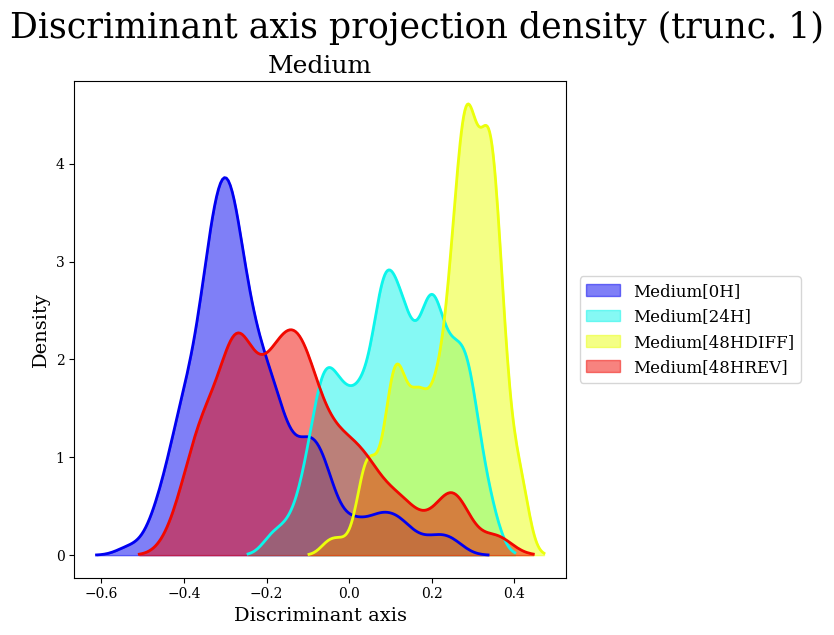

In [7]:
res.plot_density(comp=1, tests=['Medium',], colormap='jet')

(<Figure size 1600x600 with 2 Axes>,
 array([<Axes: title={'center': 'Medium'}, xlabel='Discriminant axis 1', ylabel='Discriminant axis 2'>,
        <Axes: title={'center': 'Batch'}, xlabel='Discriminant axis 1', ylabel='Discriminant axis 2'>],
       dtype=object))

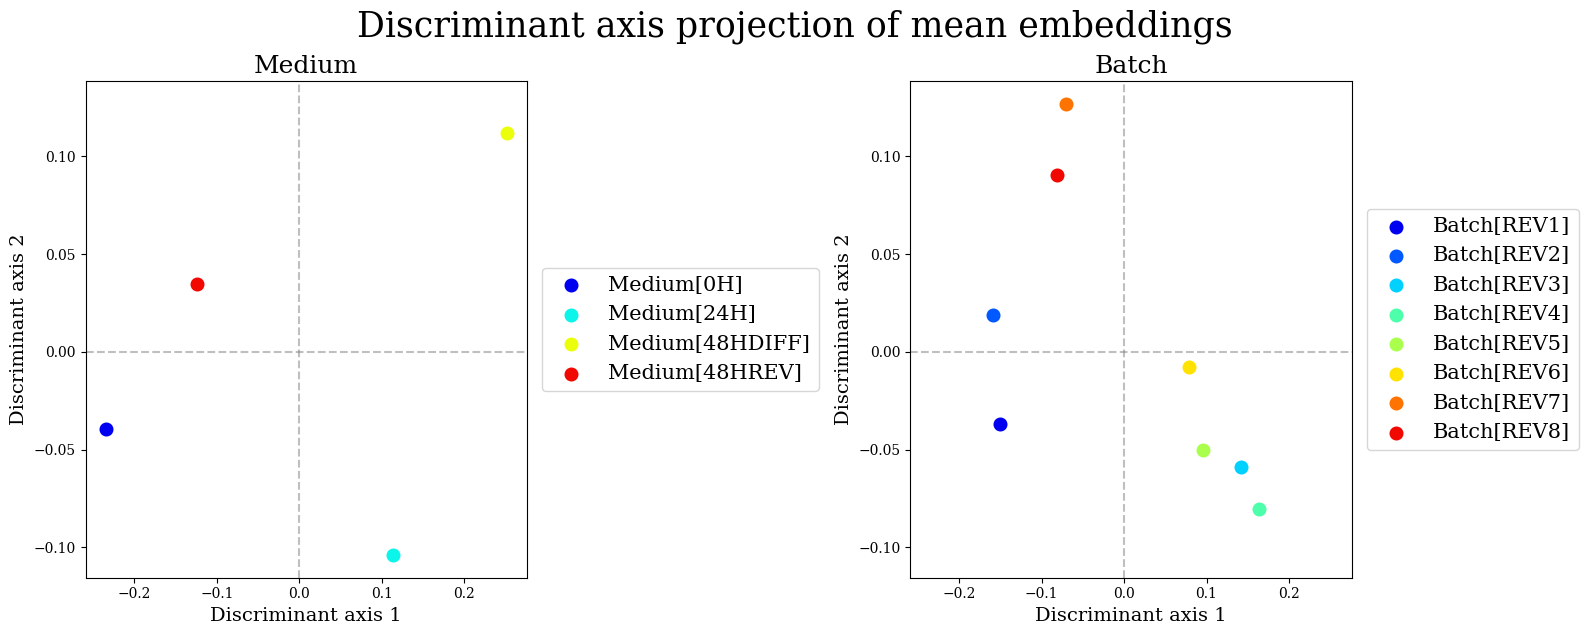

In [8]:
res.plot_mean_embedding_projections(colormap='jet')

### Study of the medium effect
We can perform pairwise comparisons of different considered media by specifying `by_level=True` and `hypotheses='pairwise'`:

In [9]:
res_pw_bl = kfit.test(by_level=True, hypotheses='pairwise', verbose=1)

-Computing the Gram matrix...
-Testing hypotheses:


100%|███████████████████████████████████████████| 34/34 [00:12<00:00,  2.68it/s]


In [10]:
print(res_pw_bl)

    Kernel Analysis of Variance (trunc. 1):
                                               
-----------------------------------------------
 Medium | factor_1_1 factor_1_2   stat    pval 
-----------------------------------------------
        |         0H        24H  58.2115 0.0000
        |         0H    48HDIFF 135.9141 0.0000
        |         0H     48HREV   0.0000 0.9997
        |        24H    48HDIFF  16.7631 0.0000
        |        24H     48HREV  57.9055 0.0000
        |    48HDIFF     48HREV 135.1675 0.0000
-----------------------------------------------
                                               
-----------------------------------------------
   Batch | factor_1_1 factor_1_2   stat   pval 
-----------------------------------------------
         |       REV1       REV2  1.4273 0.2326
         |       REV1       REV3 21.7174 0.0000
         |       REV1       REV4 28.0970 0.0000
         |       REV1       REV5  7.9975 0.0048
         |       REV1       REV6 16.1508 0.0

By default, pairwise by-level tests comparing levels of all factors are performed. Let us extract the results conserning the medium factor using `summary`:

In [11]:
res_pw_bl.summary(trunc=1, factor='Medium')

,factor_1_1,factor_1_2,stat,pval
1,0H,24H,58.21148,0.0
2,0H,48HDIFF,135.914078,0.0
3,0H,48HREV,0.0,0.999731
4,24H,48HDIFF,16.763146,0.000047
5,24H,48HREV,57.905546,0.0
6,48HDIFF,48HREV,135.167546,0.0


As expected, the most distinct medium pairs are differentiated with reverted and differentiated with non-differentiated. For the density plots, we can specify the refecrence tests of interest using the `tests` parameter:

(<Figure size 4800x600 with 6 Axes>,
 array([<Axes: title={'center': 'Medium[0H] = Medium[24H]'}, xlabel='Discriminant axis', ylabel='Density'>,
        <Axes: title={'center': 'Medium[0H] = Medium[48HDIFF]'}, xlabel='Discriminant axis', ylabel='Density'>,
        <Axes: title={'center': 'Medium[0H] = Medium[48HREV]'}, xlabel='Discriminant axis', ylabel='Density'>,
        <Axes: title={'center': 'Medium[24H] = Medium[48HDIFF]'}, xlabel='Discriminant axis', ylabel='Density'>,
        <Axes: title={'center': 'Medium[24H] = Medium[48HREV]'}, xlabel='Discriminant axis', ylabel='Density'>,
        <Axes: title={'center': 'Medium[48HDIFF] = Medium[48HREV]'}, xlabel='Discriminant axis', ylabel='Density'>],
       dtype=object))

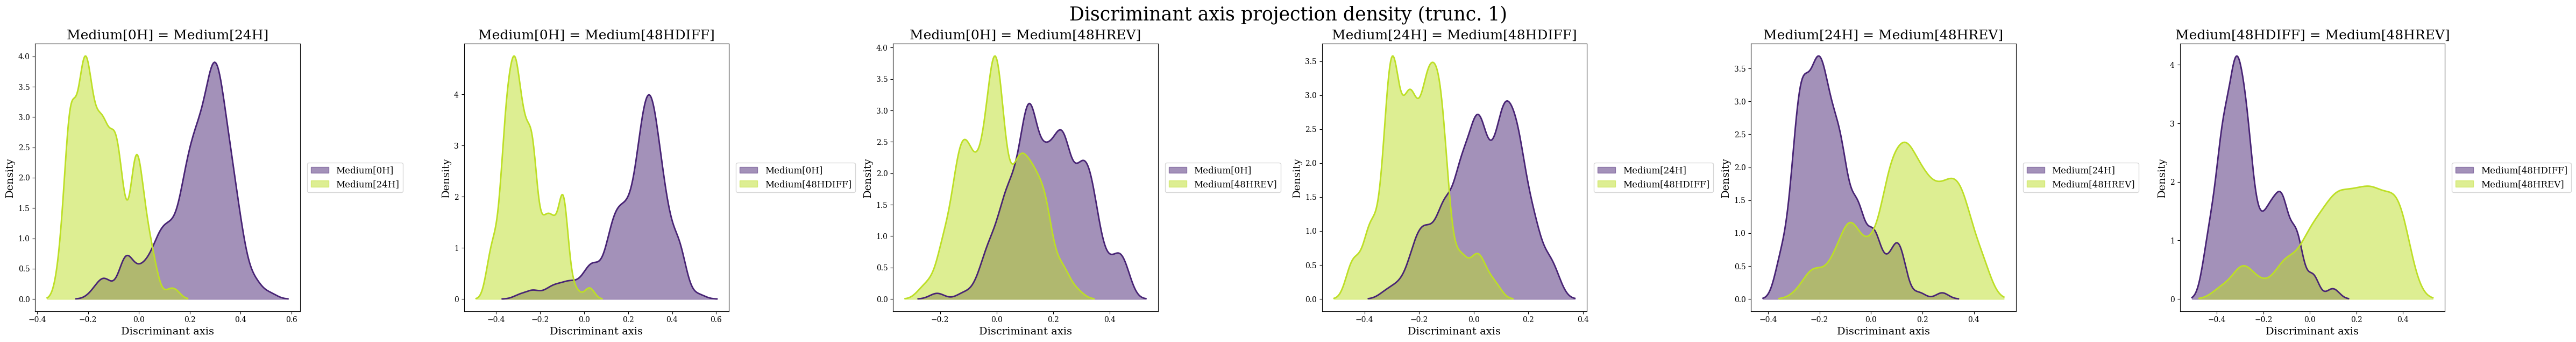

In [12]:
res_pw_bl.plot_density(comp=1, tests=[n for n, _ in res_pw_bl.hypotheses[:6]])

### Study of the batch effect
The test for the batch effect revealed that there are significant differences between batches, but are there batches that particularly stand out that could potentially introduce bias in the analysis? A first assessment can be performed by looking as the diagnostic plots, representing varios quantities of interest in the model projected onto the eigenfuctions of the residual covariance operator. By default it is the projections of the model residuals plotted against those of the predictions made by the model:

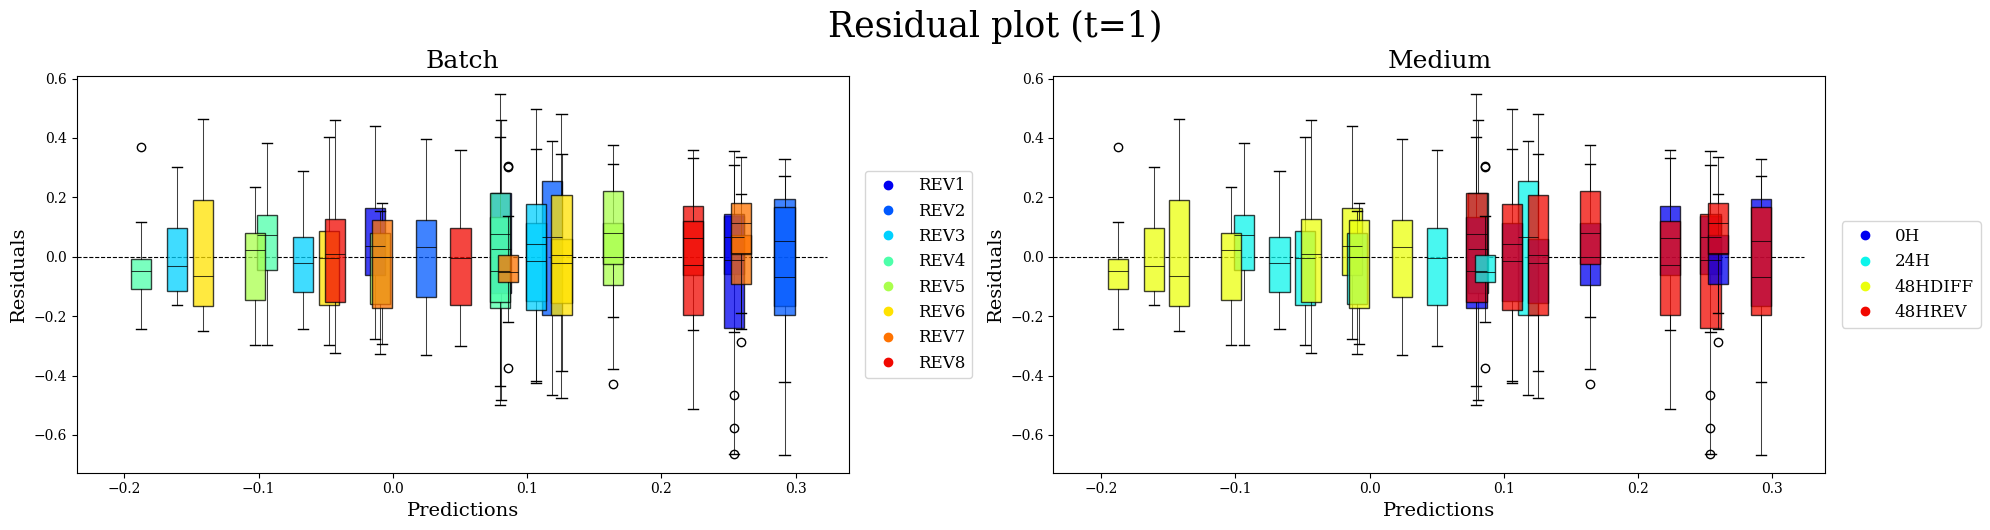

(<Figure size 2000x500 with 2 Axes>,
 array([<Axes: title={'center': 'Batch'}, xlabel='Predictions', ylabel='Residuals'>,
        <Axes: title={'center': 'Medium'}, xlabel='Predictions', ylabel='Residuals'>],
       dtype=object))

In [13]:
kfit.plot_diagnostics(trunc=1, colormap='jet', figsize=(20, 5))

Next, we can perform a series of tests comparing each batch to the mean of all batches using the by-level option with `hypotheses='one-vs-all'`:

In [14]:
res_oa_bl = kfit.test(hypotheses='one-vs-all', by_level=True, verbose=1)

-Computing the Gram matrix...
-Testing hypotheses:


100%|███████████████████████████████████████████| 12/12 [00:04<00:00,  2.80it/s]


In [15]:
res_oa_bl.summary(trunc=1, factor='Batch')

,factor_1_1,factor_1_2,stat,pval
1,REV1,Grand Mean,9.83492,0.001786
2,REV2,Grand Mean,24.563171,0.000001
3,REV3,Grand Mean,15.122884,0.000111
4,REV4,Grand Mean,23.503089,0.000002
5,REV5,Grand Mean,1.283709,0.257607
6,REV6,Grand Mean,8.589473,0.003494
7,REV7,Grand Mean,10.950288,0.000985
8,REV8,Grand Mean,2.683988,0.101821


Batches 2 and 4 appear to be the most distinct. To detect outliers on the level of individual cells, we can examine their influences on these tests ising Cook's distance. Method `plot_influence` plots these distances in function of discriminant axis projections:

(<Figure size 6400x600 with 8 Axes>,
 array([<Axes: title={'center': 'Batch[REV1] = Batch Grand Mean'}>,
        <Axes: title={'center': 'Batch[REV2] = Batch Grand Mean'}>,
        <Axes: title={'center': 'Batch[REV3] = Batch Grand Mean'}>,
        <Axes: title={'center': 'Batch[REV4] = Batch Grand Mean'}>,
        <Axes: title={'center': 'Batch[REV5] = Batch Grand Mean'}>,
        <Axes: title={'center': 'Batch[REV6] = Batch Grand Mean'}>,
        <Axes: title={'center': 'Batch[REV7] = Batch Grand Mean'}>,
        <Axes: title={'center': 'Batch[REV8] = Batch Grand Mean'}>],
       dtype=object))

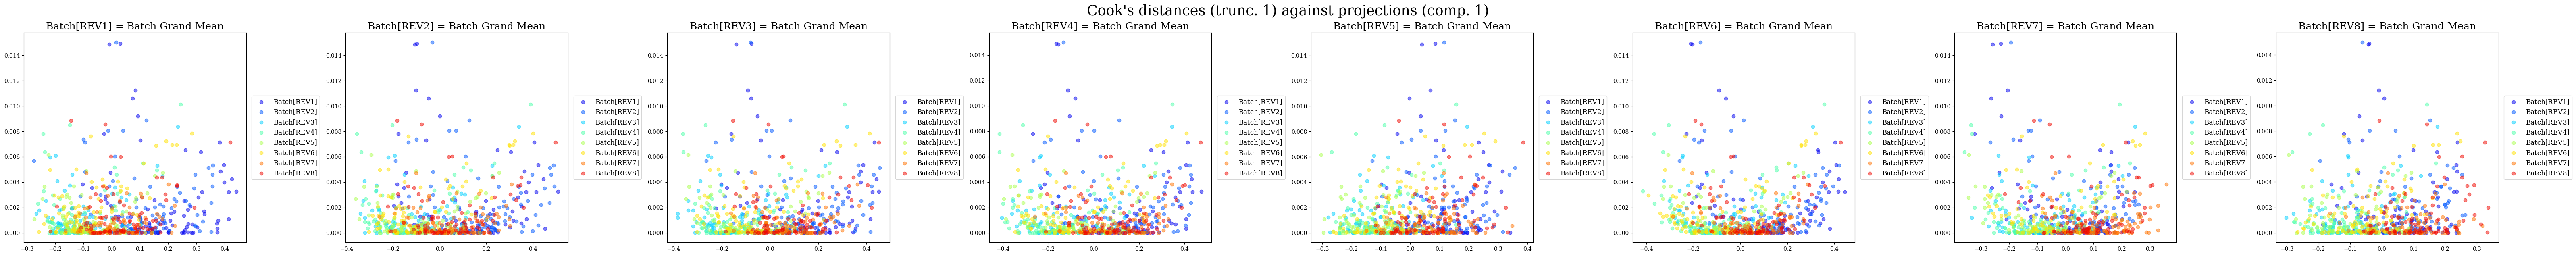

In [16]:
res_oa_bl.plot_influence(trunc=1, comp=1, tests=[n for n, _ in res_oa_bl.hypotheses[4:12]], colormap='jet')

The Cook's distances and their p-values can be accessed using the method `get_cook`:

In [13]:
cook_batch_bl = res_oa_bl.get_cook(factor='Batch', n_trunc=1)

In [14]:
cook_batch_bl.groupby('factor_1')['cook_1'].mean()

factor_1
REV1    0.003435
REV2    0.003386
REV3    0.002013
REV4    0.002247
REV5    0.001616
REV6    0.002871
REV7     0.00122
REV8    0.002147
Name: cook_1, dtype: object

Batches 1 and 2 have the biggest amount of significantly influential cells:

In [15]:
cook_batch_bl.loc[(cook_batch_bl['cook_pval_1'] < 0.05), 'factor_1'].value_counts()

factor_1
REV2    21
REV1    20
REV6    14
REV3    10
REV4     9
REV8     9
REV7     5
REV5     4
Name: count, dtype: int64

## Model with an interaction factor
Using the formula interface, we can specify a more complex model by adding an interaction effect:

In [17]:
kfit_inter = AOV.from_formula(form_exog + ' ~ C(Medium, OneHot) * C(Batch, OneHot)', 
                                data=data)

We can specifically test for the interaction effect by specifying the corresponding factor using `hypotheses_subset`:

In [19]:
res_inter = kfit_inter.test(hypotheses_subset=['Medium:Batch',])
print(res_inter)

 Kernel Analysis of Variance (trunc. 1):
                                         
-----------------------------------------
 Factor test |    factor     stat   pval 
-----------------------------------------
             | Medium:Batch 9.8741 0.0000



Next, we are interested in comparing different media in every batch. The corresponding set of hypotheses can be extracted from all by-level pairwise hypotheses using the method `set_hypotheses`:

In [20]:
hyps_inter = kfit_inter.set_hypotheses(by_level=True, hypotheses='pairwise')

In [27]:
hyps_to_test = []
for hyp_name, _ in hyps_inter:
    lvls = re.findall(r"\[(.*?)\]", hyp_name)
    if len(lvls) == 4 and lvls[1] == lvls[3]:
        hyps_to_test.append(hyp_name)

In [29]:
res_inter_pw_bl = kfit_inter.test(by_level=True, hypotheses='pairwise', hypotheses_subset=hyps_to_test, verbose=1)

-Computing the Gram matrix...
-Testing hypotheses:


100%|███████████████████████████████████████████| 48/48 [00:17<00:00,  2.69it/s]


In [30]:
print(res_inter_pw_bl)

                 Kernel Analysis of Variance (trunc. 1):
                                                                         
-------------------------------------------------------------------------
 Medium:Batch | factor_1_1 factor_2_1 factor_1_2 factor_2_2  stat   pval 
-------------------------------------------------------------------------
              |         0H       REV1        24H       REV1 0.0217 0.8830
              |         0H       REV1    48HDIFF       REV1 0.3535 0.5523
              |         0H       REV1     48HREV       REV1 1.0758 0.3000
              |        24H       REV1    48HDIFF       REV1 0.1883 0.6645
              |        24H       REV1     48HREV       REV1 1.3490 0.2459
              |    48HDIFF       REV1     48HREV       REV1 2.6484 0.1041
              |         0H       REV2        24H       REV2 0.0717 0.7890
              |         0H       REV2    48HDIFF       REV2 0.0298 0.8630
              |         0H       REV2     48HREV       

## Bibliography
S. Zreika, C. Fourneaux, E. Vallin, L. Modolo, R. Seraphin, A. Moussy, E. Ventre, M. Bouvier,
A. Ozier-Lafontaine, A. Bonnaffoux, F. Picard, O. Gandrillon, and S. Gonin-Giraud. Evidence for
close molecular proximity between reverting and undifferentiated cells. BMC Biology, 20(1):155, July
2022.